In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

path = kagglehub.dataset_download("asadullahcreative/world-population-by-country-2025")

c:\Users\hiral\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv(f"{path}/population_data.csv")

In [3]:
df.head()

,id,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,India,1463865525,0.89%,12929734,492,2973190,"−495,753",1.94,28.8,37.1%,17.78%
1,2,China,1416096094,−0.23%,"−3,225,184",151,9388211,"−268,126",1.02,40.1,67.5%,17.20%
2,3,United States,347275807,0.54%,1849236,38,9147420,1230663,1.62,38.5,82.8%,4.22%
3,4,Indonesia,285721236,0.79%,2233305,158,1811570,"−39,509",2.10,30.4,59.6%,3.47%
4,5,Pakistan,255219554,1.57%,3950390,331,770880,"−1,235,336",3.50,20.6,34.4%,3.10%


In [4]:
df.columns

Index(['id', 'Country (or dependency)', 'Population 2025', 'Yearly Change',
       'Net Change', 'Density (P/Km²)', 'Land Area (Km²)', 'Migrants (net)',
       'Fert. Rate', 'Median Age', 'Urban Pop %', 'World Share'],
      dtype='str')

In [5]:
df.describe()

,id,Population 2025,Density (P/Km²),Land Area (Km²),Fert. Rate,Median Age
count,233.000000,2.330000e+02,233.000000,2.330000e+02,233.000000,233.000000
mean,117.000000,3.532080e+07,487.673820,5.583427e+05,2.306094,31.896996
std,67.405489,1.391905e+08,2412.937646,1.694270e+06,1.134316,9.860936
min,1.000000,5.010000e+02,0.000000,0.000000e+00,0.690000,14.500000
25%,59.000000,4.663300e+05,38.000000,2.830000e+03,1.470000,22.900000
50%,117.000000,5.731206e+06,98.000000,8.220000e+04,1.940000,32.800000
75%,175.000000,2.407458e+07,256.000000,4.103400e+05,2.950000,39.800000
max,233.000000,1.463866e+09,25732.000000,1.637687e+07,5.940000,57.400000


In [6]:
df.isna().sum()

id                          0
Country (or dependency)     0
Population 2025             0
Yearly Change               0
Net Change                  0
Density (P/Km²)             0
Land Area (Km²)             0
Migrants (net)              0
Fert. Rate                  0
Median Age                  0
Urban Pop %                23
World Share                 0
dtype: int64

In [7]:
df[df['Urban Pop %'].isna()]

,id,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
52,53,Venezuela,28516896,0.39%,111353,32,882050,"−100,467",2.06,29.4,NaN,0.35%
105,106,Hong Kong,7396076,−0.25%,"−18,833",7044,1050,17863,0.73,47.4,NaN,0.090%
114,115,Singapore,5870750,0.66%,38363,8387,700,16892,0.96,36.2,NaN,0.071%
133,134,Uruguay,3384688,−0.06%,"−1,900",19,175020,"−1,338",1.39,36.4,NaN,0.041%
134,135,Puerto Rico,3235289,−0.21%,"−6,915",365,8870,5495,0.94,45.8,NaN,0.039%
152,153,Bahrain,1643332,2.26%,36283,2162,760,18128,1.78,33.4,NaN,0.020%
162,163,Réunion,882405,0.43%,3814,353,2500,"−2,585",2.13,38.1,NaN,0.011%
178,179,Guadeloupe,373791,−0.35%,"−1,315",221,1690,"−1,587",2.05,47.2,NaN,0.0045%
179,180,Martinique,340439,−0.8%,"−2,756",321,1060,"−2,491",1.97,49.7,NaN,0.0041%
199,200,U.S. Virgin Islands,84138,−0.9%,−767,240,350,−357,2.07,44.8,NaN,0.0010%


In [8]:
df['Urban Pop %']= df['Urban Pop %'].astype(str).str.replace('%','',regex=False)
df['Urban Pop %']=pd.to_numeric(df['Urban Pop %'], errors='coerce')
df['Urban Pop %']=df['Urban Pop %'].fillna(df['Urban Pop %'].median())

In [9]:
df.isna().sum()

id                         0
Country (or dependency)    0
Population 2025            0
Yearly Change              0
Net Change                 0
Density (P/Km²)            0
Land Area (Km²)            0
Migrants (net)             0
Fert. Rate                 0
Median Age                 0
Urban Pop %                0
World Share                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

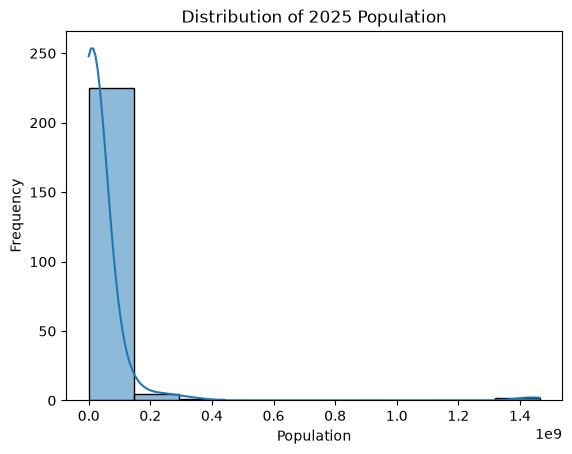

In [11]:
sns.histplot(df["Population 2025"],bins=10,kde=True)
plt.title("Distribution of 2025 Population")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

In [12]:
top_10_countries = df.sort_values(by="Population 2025",ascending=False).head(10)

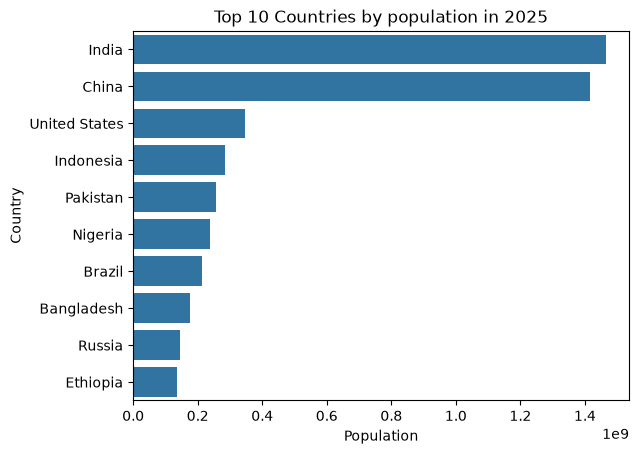

In [18]:
sns.barplot(x ="Population 2025",y = "Country (or dependency)",data= top_10_countries)
plt.title("Top 10 Countries by population in 2025")
plt.xlabel("Population")
plt.ylabel("Country")
plt.show()

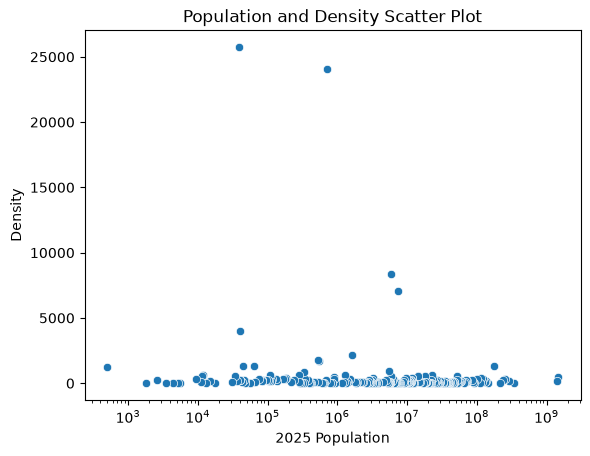

In [31]:
sns.scatterplot(x="Population 2025",y="Density (P/Km²)", data = df)
plt.title("Population and Density Scatter Plot")
plt.xlabel("2025 Population")
plt.ylabel("Density")
plt.xscale('log')
plt.show()

In [32]:
df.groupby("Country (or dependency)")["Land Area (Km²)"].sum().sort_values(ascending = False)


Country (or dependency)
Russia           16376870
China             9388211
United States     9147420
Canada            9093510
Brazil            8358140
                   ...   
Nauru                  20
Tokelau                10
Gibraltar              10
Monaco                  1
Holy See                0
Name: Land Area (Km²), Length: 233, dtype: int64

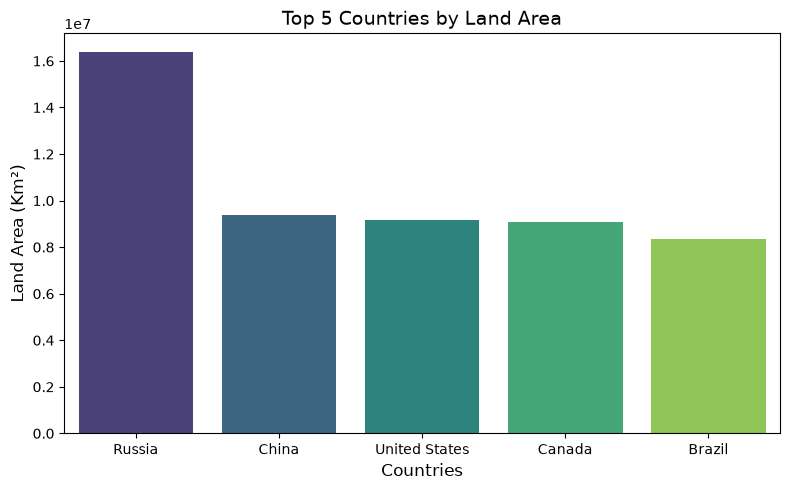

In [33]:
top_5_df = df.sort_values(by="Land Area (Km²)",ascending = False).head(5)
plt.figure(figsize=(8,5))
sns.barplot(x="Country (or dependency)",y="Land Area (Km²)", data=top_5_df,hue= "Country (or dependency)",palette="viridis",legend=False)
plt.title("Top 5 Countries by Land Area",fontsize=14)
plt.xlabel("Countries",fontsize=12)
plt.ylabel("Land Area (Km²)",fontsize=12)
plt.tight_layout()
plt.show()

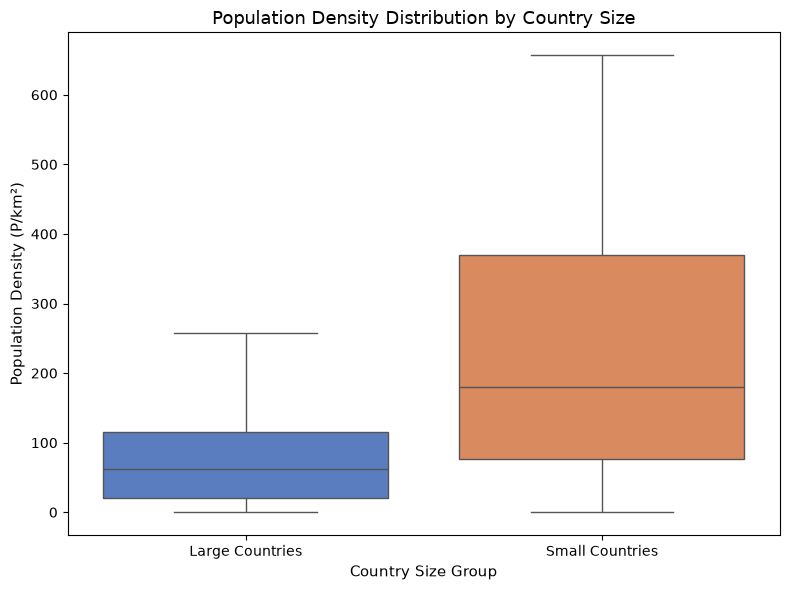

In [34]:

median_area = df["Land Area (Km²)"].median()
df["Size Category"] = np.where(df["Land Area (Km²)"] > median_area, "Large Countries", "Small Countries")
plt.figure(figsize=(8,6))
sns.boxplot( x="Size Category",y="Density (P/Km²)",data=df,hue="Size Category", palette="muted",showfliers=False)
plt.title("Population Density Distribution by Country Size", fontsize=13)
plt.xlabel("Country Size Group",fontsize=11)
plt.ylabel("Population Density (P/km²)",fontsize=11)
plt.tight_layout()
plt.show()